# [Demo] Tools

Até aqui, o agente só conversa. Aqui ele ganha a primeira **tool**: uma função Python que pode
consultar a agenda da clínica.

O que vamos ver:
- definindo uma tool com o decorator `@tool` (a docstring é o contrato);
- testando a tool isolada;
- o tool call com `bind_tools` e `response.tool_calls`;
- entregando a tool ao `create_agent` e lendo o histórico completo do ciclo ReAct.

## Intuição

<img src="resources/function-calling-diagram-steps.png" width="90%">

## Setup

Carregamos as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Definindo uma tool com @tool

Uma tool é uma função Python comum, decorada com `@tool`. A docstring funciona como o contrato: o modelo
a lê para decidir quando e como chamar a função.

In [5]:
from langchain.tools import tool

In [6]:
@tool
def find_available_slots(specialty: str, date: str) -> str:
    """Horários livres na agenda da Clínica Alura para a especialidade e data (YYYY-MM-DD)."""
    schedule = {"cardiologia": ["09:00", "10:30"], "dermatologia": ["14:00"]}
    slots = schedule.get(specialty.lower(), [])
    return f"Horários para {specialty} em {date}: {', '.join(slots) or 'nenhum'}"

## Testando a tool isolada

Antes de entregar a tool a um agente, vale testar como uma função normal, com `.invoke`.

In [7]:
find_available_slots.invoke({"specialty": "cardiologia", "date": "2026-07-20"})

'Horários para cardiologia em 2026-07-20: 09:00, 10:30'

## O tool call

`bind_tools` avisa o modelo de que existe essa opção. Diante de uma pergunta sobre a agenda, a resposta
vem como um pedido de chamada, com o nome da tool e os argumentos, em vez de texto.

In [8]:
from langchain.messages import HumanMessage

In [9]:
model_with_tools = model.bind_tools([find_available_slots])

In [10]:
response = model_with_tools.invoke([HumanMessage("Tem cardiologia dia 2026-07-20?")])

In [11]:
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 74, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e7eb9f2bc2', 'id': 'chatcmpl-EAj6wyHx55mUl0AY67cWPSvcDHUBg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe354-7eef-78c1-8185-b73820d01ac4-0', tool_calls=[{'name': 'find_available_slots', 'args': {'specialty': 'cardiologia', 'date': '2026-07-20'}, 'id': 'call_gOAxBPZsSNCUTzfeq3vprGcZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 27, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}

In [12]:
response.tool_calls

[{'name': 'find_available_slots',
  'args': {'specialty': 'cardiologia', 'date': '2026-07-20'},
  'id': 'call_gOAxBPZsSNCUTzfeq3vprGcZ',
  'type': 'tool_call'}]

In [13]:
# executando a chamada pedida pelo modelo, na mão
find_available_slots.invoke(response.tool_calls[0]["args"])

'Horários para cardiologia em 2026-07-20: 09:00, 10:30'

## Entregando a tool ao create_agent

Fazer esse ciclo na mão (chamar a tool, pegar o resultado, mandar de volta pro modelo) fica repetitivo com
várias perguntas. O `create_agent` automatiza esse ciclo ReAct completo: basta entregar a tool na lista
`tools`.

In [14]:
from langchain.agents import create_agent
from IPython.display import Image, display

In [16]:
agent = create_agent(
    model=model,
    tools=[find_available_slots],
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
)

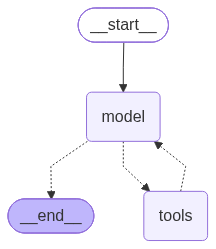

In [17]:
display(
    Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0))
)

## Lendo o histórico do ciclo ReAct

O grafo agora tem um nó de tools. A lista de mensagens da resposta mostra o ciclo completo: a pergunta do
paciente, o pedido de chamada do modelo, o resultado da tool e, só então, a resposta final.

In [18]:
response = agent.invoke({"messages": [HumanMessage("Tem cardiologia dia 2026-07-20?")]})

In [19]:
response["messages"]

[HumanMessage(content='Tem cardiologia dia 2026-07-20?', additional_kwargs={}, response_metadata={}, id='9aadfccf-714d-4de6-9124-39bb6ed13c60'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 95, 'total_tokens': 122, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6339e52f56', 'id': 'chatcmpl-EAj8uombjozLTCYP2ApX0dz0YgI3r', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe356-5bad-7030-b8da-7df29f3e24e1-0', tool_calls=[{'name': 'find_available_slots', 'args': {'specialty': 'cardiologia', 'date': '2026-07-20'}, 'id': 'call_Vrz6c6vn1s6W3t5Crznac9cn', 'type': 'tool_call'}], invalid

In [20]:
print(response["messages"][-1].content)

Sim, temos horários disponíveis para cardiologia no dia 20 de julho de 2026, às 09:00 e 10:30.


## Múltiplas tools

Com uma tool só, o agente sempre chama a mesma função. A autonomia real aparece quando ele escolhe, sozinho,
entre várias opções, inclusive mais de uma na mesma pergunta. Vamos dar à Clínica Alura mais três tools.

In [21]:
@tool
def get_clinic_hours(day_of_week: str) -> str:
    """Horário de atendimento da Clínica Alura no dia da semana informado, em português (ex.: 'segunda')."""
    hours = {
        "segunda": "08:00 às 18:00",
        "terça": "08:00 às 18:00",
        "quarta": "08:00 às 18:00",
        "quinta": "08:00 às 18:00",
        "sexta": "08:00 às 17:00",
        "sábado": "08:00 às 12:00",
        "domingo": "fechado",
    }
    return f"Atendimento às {day_of_week}: {hours.get(day_of_week.lower(), 'dia não reconhecido')}"

In [22]:
@tool
def list_specialties() -> str:
    """Lista as especialidades médicas atendidas pela Clínica Alura."""
    specialties = ["cardiologia", "dermatologia", "clínica geral"]
    return f"Especialidades atendidas: {', '.join(specialties)}"

In [23]:
@tool
def estimate_consultation_price(specialty: str) -> str:
    """Preço estimado da consulta particular por especialidade na Clínica Alura."""
    prices = {"cardiologia": 350, "dermatologia": 280, "clínica geral": 200}
    price = prices.get(specialty.lower())
    return f"Consulta de {specialty}: R$ {price}" if price else f"Sem preço cadastrado para {specialty}."

In [24]:
tools = [find_available_slots, get_clinic_hours, list_specialties, estimate_consultation_price]

In [25]:
agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva. "
                   "Use as tools disponíveis sempre que precisar de dados da clínica.",
)

In [26]:
patient_message = """
Oi! Fiquei com algumas dúvidas:Quais especialidades a clínica atende? 
Vocês atendem no Domingo? Se não, que horas vocês abrem na segunda-feira? 
E ah, quanto custa em média uma consulta de dermatologia?
"""

In [27]:
response = agent.invoke({"messages": [HumanMessage(patient_message)]})

In [28]:
print(response["messages"][-1].content)

Olá! 

1. As especialidades atendidas pela clínica são: **cardiologia, dermatologia e clínica geral**.
2. Não atendemos aos domingos. Na **segunda-feira**, estamos abertos das **08:00 às 18:00**.
3. O preço médio de uma consulta de **dermatologia** é de **R$ 280**.

Se precisar de mais alguma informação, estou à disposição!


Uma pergunta, quatro tools diferentes. O histórico completo mostra o agente decidindo, a cada rodada, qual
delas chamar.

In [29]:
response["messages"]

[HumanMessage(content='\nOi! Fiquei com algumas dúvidas:Quais especialidades a clínica atende? \nVocês atendem no Domingo? Se não, que horas vocês abrem na segunda-feira? \nE ah, quanto custa em média uma consulta de dermatologia?\n', additional_kwargs={}, response_metadata={}, id='3291c276-aeec-4680-84a6-ac8440aafb80'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 240, 'total_tokens': 325, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6339e52f56', 'id': 'chatcmpl-EAjAvlTis5GCCqDvXyuzKKgOfrcBG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe358-4477-7b33-8d7c-c13cb89faf61

## Takeaway

Uma tool já tira o agente do modo só-conversa. Com várias, ele decide sozinho quais chamar e em que ordem,
mesmo dentro de uma única pergunta com várias partes. Esse mesmo agente é a base do produto: a CLI
`clinica-alura`.